### Spam Screening for an Email Service Provider

[Business Report](./README.md)

**Problem Statement**

Email Service Providers (such as SendGrid, Mailchimp) need to maintain and protect the trust of the email channel; can the subject and body of an outbound message be scanned and used to detect and block spam before delivery?

An email service provider's traffic is inherently "open" in that customers (or potentially customers of their customers) send mail that is potentially spam.  A spam filter trained narrowly on a focused data set or singular writing style risks two failure modes on emails that don't resemble the training set - missing spam that doesn't resemble the training examples, or misclassifying legitimate email as spam.

This project asks whether the subject and body text of an outbound email can be used to reliably screen for spam against this business context.

**Goals**:
- Build a binary spam classifier from email subject/body text
- Evaluate for production readiness, weighing quality against inference cost

**Business Context - Why False Positives Matter**

Not all classification errors have equal impact in this business context.  A spam classifier makes two types of mistakes:

- **False negative**.  Spam gets through, which negatively impacts the email service provider's trust level with email ecosystem (such as reputation via [M3AAWG](https://www.m3aawg.org/).  If too much spam is delivered to the ecosystem by the email service provider, negative scoring by M3AAWG and other groups will reduce *deliverability* (which is ultimately what customers are paying for - email landing in their customer's inboxes).

- **False positives**.  Legitimate traffic gets blocked, which directly impacts their customer's ability to operate their business.  Immediacy of impact differs between annoying (marketing messages get delayed), and mission critical (one time passwords and magic links get blocked).

Any viable model must balance these, trading off ecosystem trust with individual customer impact in an inherently adversarial landscape (including account takeovers, where hostile actors use trusted customer credentials to deliver spam).

This notebook tracks precision, recall, F1 and ROC-AUC for every model, but treats **precision** as the key metric that a model has to clear before it's deemed worthy of production.  F1 is the practical target for model selection and hyperparameter optimization, as it forces the trade-off balancing precision and recall.

#### How to Read this Notebook

This notebook documents the technical journey through building, training and validating the classifier.  It includes regressions and issues on purpose, as well as the final results and recommendations.

Sections, grouped by phase:

- **Data and EDA** - [Setup](#setup), [Data Acquisition](#data-acquisition), [Data Cleaning](#data-cleaning), [Feature Engineering](#feature-engineering), [Exploratory Data Analysis](#exploratory-data-analysis)
- **Methodology** - [Experimental Design](#experimental-design), [Initial Baseline and Generalization Gap](#initial-baseline-and-generalization-gap)
- **Model development and the tokenizer investigation** — [Initial Multi-Family Training Runs and Tokenizer Regression](#initial-multi-family-training-runs-and-tokenizer-regression), [Enabling GPU Training (RTX5090)](#enabling-gpu-training-rtx5090), [Establishing Baseline Performance](#establishing-baseline-performance), [Baseline Observations](#baseline-observations), [Round Trip Breaks on Unicode](#round-trip-breaks-on-unicode), [Switching to a Custom Tokenizer (and Performance Regression)](#switching-to-a-custom-tokenizer-and-performance-regression), [Hyperparameter Tuning](#hyperparameter-tuning)
- **Results and production readiness** — [Final Model Selection and Metric Analysis](#final-model-selection-and-metric-analysis), [Production Inference and Load Testing](#production-inference-and-load-testing)
- **Wrap-up** — [Conclusions and Next Steps](#conclusions-and-next-steps), [Engineering Retrospective - Key Learnings](#engineering-retrospective---key-learnings)

For the summary of results and recommendations see [README.md](./README.md).

#### Prerequisites

The project and notebook depend on `uv` for the Python environment and dependency management.  Install [uv](https://docs.astral.sh/uv/), then run `uv sync` in the repo root.  Start the local venv via `source .venv/bin/activate`, then launch the notebook.

For MacOS:
```bash
brew install uv
uv sync
source .venv/bin/activate 
```

The trained weights are checked in via Git LFS, which requires the following in order to use them to run the inference tests.

```bash
git lfs install
git lfs pull
```

Linux directions will depend on the distribution, and will require downloading the custom tensorflow wheel with RTX5090 support that this notebook and project expects.

#### Setup

This notebook imports functions from the `capstone` package used to perform the training, testing and inference validation described later in the notebook.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt
import json
import kagglehub

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Leverage Fthe data preparation / training / testing code used by the training CLI and the inference run time
from capstone.prep import prep_data
from capstone.dataset import build_dataset
from capstone.features import summarize_features, CORE_COLUMNS
from capstone.evaluate import evaluate_model

# Keep displayed tables readable; email bodies can be very long
pd.set_option("display.max_colwidth", 80)

# Avoid scientific notation, format floats consistently
pd.set_option("display.float_format", lambda v: f"{v:,.0f}" if float(v).is_integer() else f"{v:,.4f}")


#### Data Acquisition

Source: Kaggle dataset `nitishabharathi/email-spam-dataset`, downloaded via `kagglehub` apis, and cached locally.

The dataset holds three separate email data files:

| Source           | Description |
|------------------|---------------------------------------------------------------|
| **Enron**        | Emails from the 2001 Enron collapse. Released by Andrew McCallum. Packaged by CMU. |
| **SpamAssassin** | Collected by Justin Mason, 2002-2003. Built as a test set for spam filter developers. |
| **LingSpam**     | Collected by NCSR Demokritos, 2000. Built from a linguistics mailing list. |

Each source has a `Body` column (raw text), and a `Label` column (`1` = spam, `0` = not spam / ham)

In [2]:
path = kagglehub.dataset_download("nitishabharathi/email-spam-dataset")

raw_data_sets = {
    "Enron": pd.read_csv(f"{path}/enronSpamSubset.csv"),
    "Spam Assassin": pd.read_csv(f"{path}/completeSpamAssassin.csv"),
    "LingSpam": pd.read_csv(f"{path}/lingSpam.csv")
}

In [3]:
def summarize_source(df: pd.DataFrame, label_col: str) -> dict:
    return {
        "rows": len(df),
        "cols": df.shape[1],
        "ham": int((df[label_col] == 0).sum()),
        "spam": int((df[label_col] == 1).sum()),
        "spam_rate": df[label_col].mean(),
        "missing_body": int(df["Body"].isna().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }

pd.DataFrame({name: summarize_source(df, "Label") for name, df in raw_data_sets.items()})

,Enron,Spam Assassin,LingSpam
rows,"10,000","6,046","2,605"
cols,4,3,3
ham,"5,000","4,150","2,172"
spam,"5,000","1,896",433
spam_rate,0.5000,0.3136,0.1662
missing_body,0,1,0
duplicate_rows,0,0,0


#### Data Cleaning

The `capstone.prep_data` function:

- Splits `Subject:` from `Body:`
- Drops rows with no body
- Replaces several Unicode line break characters with spaces (some tokenizers only support ASCII)

Bug history: an earlier version split every row on `Subject:` without a check, which failed when introducing the `SpamAssassin` data set.

In [4]:
cleaned = {
    name: prep_data(df, name, "Body", "Subject", "Label") for name, df in raw_data_sets.items()    
}

def summarize_cleaning(df_raw: pd.DataFrame, df_clean: pd.DataFrame) -> dict:
    return { 
        "rows_in": len(df_raw),
        "rows_out": len(df_clean),
        "rows_dropped": len(df_raw) - len(df_clean),
        "empty_subject_rate": (df_clean["Subject"] == "").mean()
    }
pd.DataFrame({name: summarize_cleaning(raw_data_sets[name], df) for name, df in cleaned.items()})

,Enron,Spam Assassin,LingSpam
rows_in,"10,000","6,046","2,605"
rows_out,"10,000","6,045","2,605"
rows_dropped,0,1,0
empty_subject_rate,0.0091,1,0.0238


#### Feature Engineering

The `capstone.features.engineer_features` function builds structural features from the subject and body text, extracting:

- Character length, word count
- Capitalization ratio, digit ratio
- Counts of punctuation characters (spam tends to heavily use characters such as '!', '$', etc)
- Embedded links (`http://` and `www` checked separately)

Each feature is extracted for the subject and the body.  A representative subset of the 77 features is shown below.  Note that these are candidate features, many of which are pruned later in the flow.

In [5]:
# Prep data, engineer features per source, concatenate 
df_all = build_dataset(raw_data_sets)
feature_cols = [c for c in df_all.columns if c not in CORE_COLUMNS]

summarize_features(df_all)

,count,list
category,,
shape/ratio features,8,"[subject_length, subject_word_count, subject_upper_ratio, subject_digit_rati..."
embedded/link flags,4,"[subject_has_http_url, subject_has_web_url, body_has_http_url, body_has_web_..."
punctuation counts,64,"[subject_exclaim_count, subject_dquote_count, subject_hash_count, subject_do..."
other,1,[has_subject]


#### Exploratory Data Analysis

Two areas of investigation (covered in more detail in [data-exploration](./data-exploration.ipynb)):

1. Do these features help to separate ham from spam.  Compare the feature value distribution across labels.
2. Are there outlier values regardless of label?  In this context outliers are flagged not dropped, as these can be valuable indicators of spam (dropping outliers might remove signal, not noise).

In [6]:
# First drop features with no variation across labels (a feature with a single distinct value across 
# every row carries no useful signal).
constant_features = [c for c in feature_cols if df_all[c].nunique() == 1]
feature_cols_eda = [c for c in feature_cols if c not in constant_features]

print(f"Dropped {len(constant_features)} constant feature(s): {constant_features}")
print(f"{len(feature_cols_eda)} features remain.")

Dropped 3 constant feature(s): ['subject_upper_ratio', 'subject_has_http_url', 'subject_has_web_url']
74 features remain.


In [7]:
def label_separation(df: pd.DataFrame, feature: str, label_col: str = "Label") -> float:
    auc = roc_auc_score(df[label_col], df[feature])
    return abs(auc-0.5)

separation = pd.Series({f : label_separation(df_all, f) for f in feature_cols_eda}, name="separation").sort_values(ascending=False)



In [8]:
def feature_kind(feature: str) -> str:
    if feature.endswith(("_has_http_url", "_has_web_url")):
        return "flag"
    if feature.endswith(("_upper_ratio", "_digit_ratio")):
        return "ratio"
    return "count"

def plot_feature(ax, feature):
    kind = feature_kind(feature)
    if kind == "flag":        
        rates = df_all.groupby("Label")[feature].mean()
        ax.bar(["Ham (0)", "Spam (1)"], [rates.get(0, 0), rates.get(1, 0)])
        ax.set_ylim(0, 1)
        ax.set_ylabel("Proportion of messages")
    elif kind == "count":
        sns.boxplot(data=df_all.assign(_plotted=np.log1p(df_all[feature])), x="Label", y="_plotted", ax=ax)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Ham (0)", "Spam (1)"])
        ax.set_ylabel("log(1 + count)")
    else:
        sns.boxplot(data=df_all, x="Label", y=feature, ax=ax)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Ham (0)", "Spam (1)"])
    ax.set_title(feature.replace("_", " "), fontsize=10)
    ax.set_xlabel("")

# Plot the 12 most "relevant" features
most_relevant = 12
curated_features = separation.head(most_relevant).index.tolist()
separation.head(most_relevant).to_frame()


,separation
body_exclaim_count,0.1856
body_colon_count,0.1702
body_slash_count,0.1526
body_rparen_count,0.1493
body_lparen_count,0.1453
body_hyphen_count,0.1436
body_at_count,0.1282
body_gt_count,0.1182
body_digit_ratio,0.1130
body_comma_count,0.1125


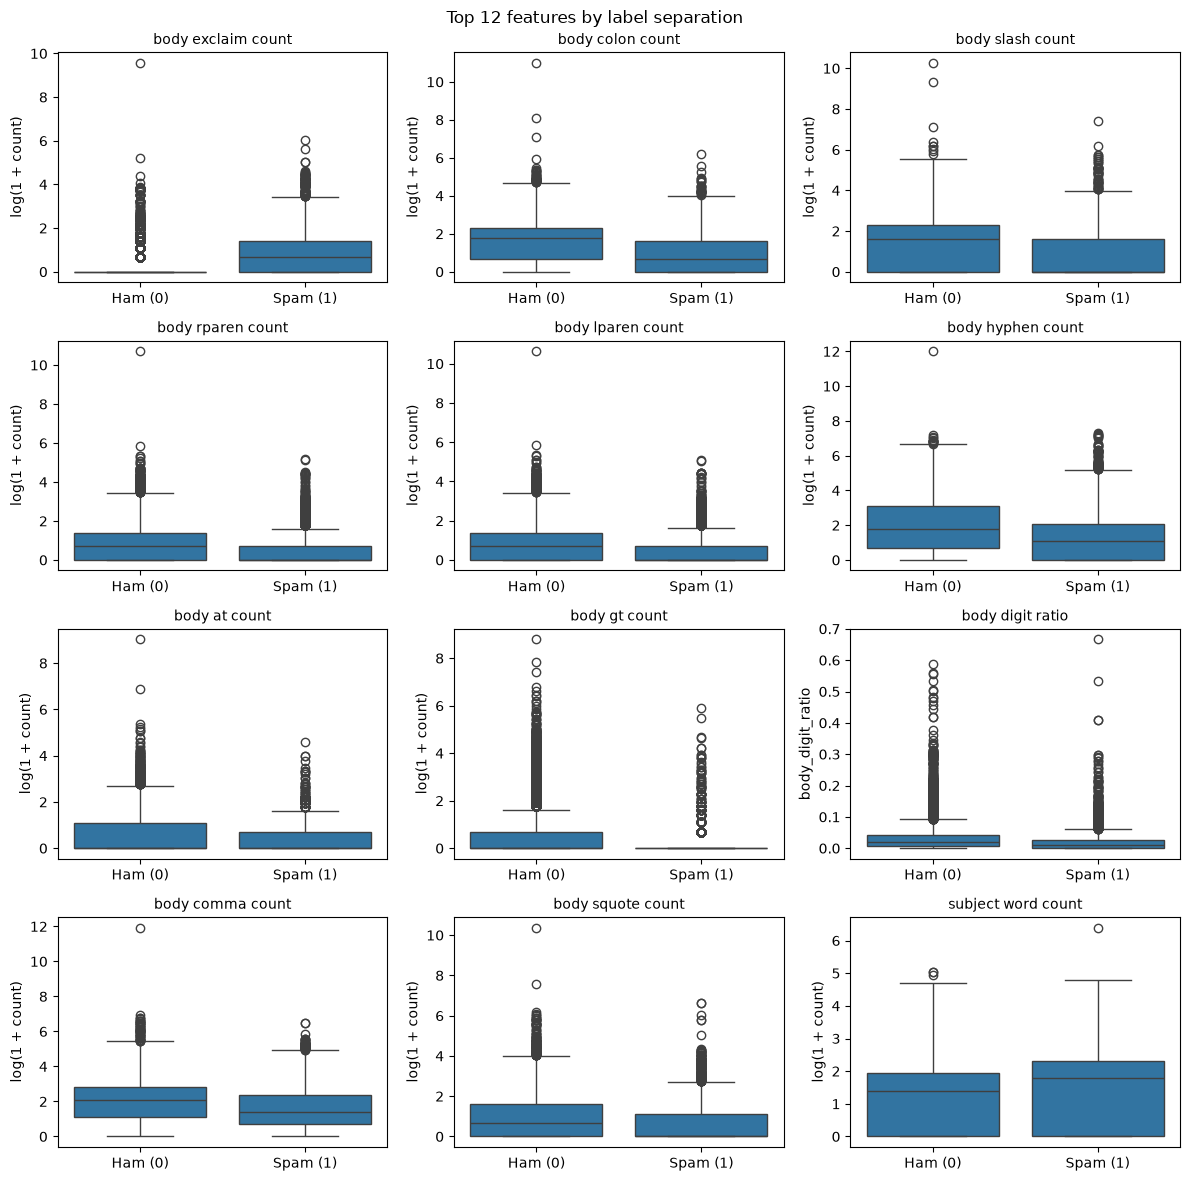

In [9]:
n_cols = 3
n_rows = math.ceil(len(curated_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, curated_features):
    plot_feature(ax, feature)
for ax in axes[len(curated_features):]:
    ax.set_visible(False)

fig.suptitle(f"Top {most_relevant} features by label separation")
plt.tight_layout()
plt.show()

#### Experimental Design

Two approaches were taken through this project:

| Phase | Approach | Learning |
| ----- | -------- | -------- |
| Initial Baseline | Train on the Enron data set only, test on SpamAssassin and LingSpam. | Model did not work well on SpamAssassin or LingSpam data.  Learned the specific writing style, did not generalize.  Need a more diverse training data set.
| Consolidated | Combined all three data sets to create a consolidated set via `prepare_experiment`, split into training and test sets (stratified) at an 80/20 split.

All training and validation after the initial baseline used the consolidated data set; the classic model, DNN model, and tuning thereof measure performance across the known data set.  

The test of "generalize to an unknown data set" was deferred due to lack of a fresh externalized validation set (see Conclusions for next steps).

#### Initial Baseline and Generalization Gap

Demonstrating method 1 from the prior section, training TF-IDF + Multinomial Naive Bayes on the Enron data set, testing on all three.

In [10]:
def prep_for_baseline(df : pd.DataFrame, source_name: str) -> pd.DataFrame:
    df_source = df[df["Source"] == source_name].copy()
    df_source["text"] = df_source["Subject"] + " " + df_source["Body"]
    return df_source.drop_duplicates(subset=["text"], keep="first")


df_enron = prep_for_baseline(df_all, "Enron")
df_train_enron, df_test_enron = train_test_split(
    df_enron, test_size=0.2, stratify=df_enron["Label"], random_state=42
)
vectorizer = TfidfVectorizer(stop_words="english")
X_train = vectorizer.fit_transform(df_train_enron["text"])

base_model = MultinomialNB()
base_model.fit(X_train, df_train_enron["Label"])


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3941.,3808.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.68,-0.71]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 76112)","[[49.1 ,42.63, 0.22,..., 0. , 0. , 0. ], [28.49,31.54, 6.17,..., 0.05, 0.05, 0.67]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 76112)","[[ -7.61, -7.75,-11.33,...,-11.53,-11.53,-11.53], [ -8.16, -8.07, -9.58,...,-11.5 ,-11.5 ,-11.04]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,76112


In [11]:
evaluation_sets = {
    "Enron (test)": df_test_enron,
    "Spam Assassin": prep_for_baseline(df_all, "Spam Assassin"),
    "LingSpam": prep_for_baseline(df_all, "LingSpam"),
}

def base_model_predict_proba(df: pd.DataFrame) -> np.ndarray:
    return base_model.predict_proba(vectorizer.transform(df["text"]))[:, 1]

results = { 
    name: evaluate_model(base_model_predict_proba, df, "Label") for name, df in evaluation_sets.items()
}

In [12]:
metrics = ["precision", "recall", "f1", "roc_auc"]
df_comp = pd.DataFrame([
    { "dataset": name, "metric": metric, "value": result[metric] }
    for name, result in results.items()
    for metric in metrics
])
df_comp.pivot(index="dataset", columns="metric", values="value")


metric,f1,precision,recall,roc_auc
dataset,,,,
Enron (test),0.9868,0.9926,0.9811,0.9993
LingSpam,0.6923,0.5422,0.9574,0.9726
Spam Assassin,0.4981,0.3346,0.9739,0.9031


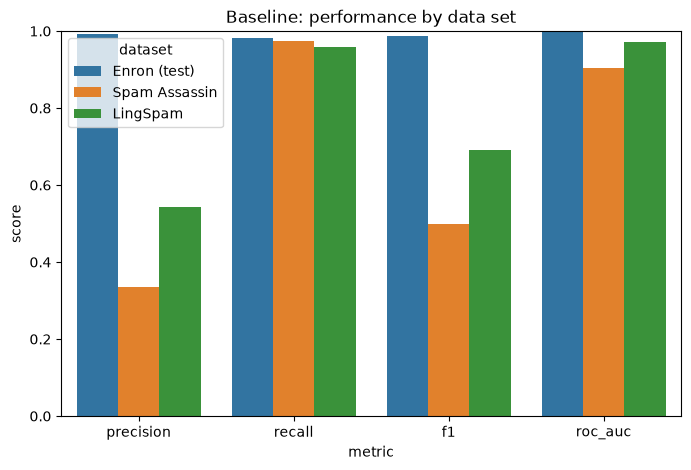

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_comp, x="metric", y="value", hue="dataset", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("Baseline: performance by data set")
plt.show()

#### Initial Multi-Family Training Runs and Tokenizer Regression

After establishing the baseline at the EDA step, the training and validation code was refactored to be executable by both a notebook environment and a CLI (see artifacts in [src/capstone](./src/capstone/)).  
From here forward, the notebook switches from model exploration to model comparison.  

The cli started by enabling automation of `train` operations against a either a `classic` or `dnn` model with provided hyperparameters, invoked as:

```bash
uv run python -m capstone.cli --verbose info [classic|dnn] train \
    --directory "$DIRECTORY" \
    --config configs/classic/baseline.json \
    --output artifacts/classic_baseline
```

The training harness was implemented in the `run_classic_batch.sh` and `run_dnn_batch.sh` scripts, which iterated over configurations.   The cli used the built-in functions from scikit-learn and keras to save model weights for later inference.


#### Enabling GPU Training (RTX5090)

As part of the learning exercise, one meta goal was to leverage GPU-accelerated training, and compare the training efficiency vs. CPU only training.  The target (available) hardware was a device with an Nvidia RTX5090 with 32 GB of VRAM.  As no public Tensorflow [release](https://github.com/tensorflow/tensorflow/releases) supported the RTX5090, a custom wheel needed to be built specifically supporting this card.

The script to install the necessary dependencies (on an OpenSuse Leap 16 distribution) is captured in [build-tensorflow.sh](./dependencies/build-tensorflow.sh), the result of which is also checked in via LFS.

To build the wheel locally execute `dependencies/build-tensorflow.sh`, which executes:

```bash
bazel build //tensorflow/tools/pip_package:wheel \
    --repo_env=WHEEL_NAME=tensorflow \
    --repo_env=ML_WHEEL_VERSION_SUFFIX=+rtx5090.cuda13 \
    --config=cuda_wheel --config=opt \
    --copt=-march=native --host_copt=-march=native \
    --repo_env=HERMETIC_CUDA_VERSION=13.0.0 \
    --repo_env=HERMETIC_CUDNN_VERSION=9.12.0 \
    --repo_env=HERMETIC_CUDA_COMPUTE_CAPABILITIES=12.0 \
    --@local_config_cuda//:cuda_compiler=nvcc
```

The key parameters are `HERMETIC_CUDA_COMPUTE_CAPABILITIES=12.0` which brings in support for `sm120` (the chip family for the RTX5090), and using the `nvcc` compiler as llvm20 does not yet support that `sm120` target.

To use the checked in tool dependency, use git's LFS support:

```bash
git lfs install
git lfs pull
```

#### Establishing Baseline Performance

The first iteration of the training focused on evaluating two model families, trained and validated on the combined train/test split across the three data sets with engineered features.

**Classic**: `ColumnTransformer` combining a TF-IDF vectorizer over the text with a `StandardScaler` on the engineered features feeding into a `LogisticRegression`.  Two iterations, the [baseline](./configs/classic/baseline.json) with `clf__C=10, max_features=20000,  ngram_range=(1,1)`, and [wider_ngram](./configs/classic/wider_ngrams.json) to evaluate the impact of `ngram_range = (1, 2)`

```python
def build_classical_pipeline(feature_cols: list[str]) -> Pipeline:
    preprocessor = ColumnTransformer([
        ("tfidf", TfidfVectorizer(stop_words="english"), "text"),
        ("engineered", StandardScaler(), feature_cols)
    ])
    return Pipeline([
        ("features", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])
```

**DNN**: two input branches (text and features), fused before the output layer.  The text branch runs Keras' `TextVectorization` through an `Embedding` then an `LSTM`.  The numeric branch runs the engineered features through a `Normalization` layer.  Both concatenate into a `Dense` layer, then `Dropout` then a `sigmoid` output.

The baseline run set `use_cudnn="auto"` to allow tensorflow to take advantage of cuDNN (NVidia's CUDA deep neural network library for GPU optimization of common deep learning operations such as LSTM) if available, and used the defaults of `max_tokens=20_000, output_sequence_length=3000, embedding_dim=64, lstm_units=64, dense_units=32, dropout_rate=0.3, learning_rate=1e-3`.  Variations on a larger LSTM value were trained, as well as the training time impact of disabling cudnn.

```python
vectorize_layer = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=output_sequence_length,
    name="text_vectorization"
)
vectorize_layer.adapt(train_text)

text_branch = vectorize_layer(text_input)
text_branch = keras.layers.Embedding(max_tokens, embedding_dim, mask_zero=True)(text_branch)
text_branch = keras.layers.LSTM(lstm_units, use_cudnn=use_cudnn)(text_branch)

numeric_branch = normalizer(numeric_input)
merged = keras.layers.Concatenate()([text_branch, numeric_branch])
x = keras.layers.Dense(dense_units, activation="relu")(merged)
x = keras.layers.Dropout(dropout_rate)(x)
output = keras.layers.Dense(1, activation="sigmoid")(x)
```


In [14]:
# Display the baseline runs
built_in_paths = {
    "classic_baseline": "artifacts/built-in-tokenizer/classic_baseline.metrics.json",
    "classic_wider_ngrams": "artifacts/built-in-tokenizer/classic_wider_ngrams.metrics.json",
    "dnn_baseline": "artifacts/built-in-tokenizer/dnn_baseline.metrics.json",
    "dnn_larger_lstm": "artifacts/built-in-tokenizer/dnn_larger_lstm.metrics.json",
    "dnn_no_cudnn": "artifacts/built-in-tokenizer/dnn_no_cudnn.metrics.json",
    "dnn_baseline_nocpu": "artifacts/built-in-tokenizer/dnn_baseline_nocpu.metrics.json",
}

rows = []
for name, path in built_in_paths.items():
    m = json.loads(Path(path).read_text())["metrics"]
    rows.append({"run": name, "precision": m["precision"], "recall": m["recall"], "f1": m["f1"], "roc_auc": m["roc_auc"]})

pd.DataFrame(rows).set_index("run")

,precision,recall,f1,roc_auc
run,,,,
classic_baseline,0.9708,0.9870,0.9788,0.9973
classic_wider_ngrams,0.9694,0.9893,0.9793,0.9973
dnn_baseline,0.9621,0.9672,0.9647,0.9951
dnn_larger_lstm,0.9678,0.9619,0.9648,0.9959
dnn_no_cudnn,0.9526,0.9802,0.9662,0.9947
dnn_baseline_nocpu,0.9275,0.9657,0.9462,0.9911


#### Baseline Observations

| Run | Hyperparameters | F1 | ROC-AUC | Duration (s) | Key Learning |
| --- | --- | --- | --- | --- | --- |
| `classic_baseline` | `C=10`, `max_features=20000`, `ngram_range=(1,1)` | 0.9788 | 0.9973 | 30 | Strong TF-IDF + LogReg baseline, fast to train. |
| `classic_wider_ngrams` | `C=10`, `max_features=20000`, `ngram_range=(1,2)` | 0.9793 | 0.9973 | 35 | Bigrams gave a small, real F1 gain, mostly from higher recall, at negligible extra cost. |
| `dnn_baseline` | `embed=64`, `lstm=64` (defaults), `use_cudnn=auto` | 0.9647 | 0.9951 | 65 | The LSTM trails the linear baseline out of the box |
| `dnn_larger_lstm` | `embed=128`, `lstm=128` | 0.9648 | 0.9959 | 91 | Doubling embed/units didn't move F1 — bigger wasn't better here either |
| `dnn_no_cudnn` | `use_cudnn=False` | 0.9662 | 0.9947 | 3429 | Disabling cuDNN cost a ~53x slowdown for no quality gain — the clearest demonstration in the whole project that cuDNN is a speed lever, not a quality lever. |
| `dnn_baseline_nocpu` | CPU only (`GPU_MODE=force_cpu`) | 0.9462 | 0.9911 | 1320 | The one pre-swap DNN run with a real quality drop, not just a speed cost — worth a second look rather than assuming it's noise. |


#### Round Trip Breaks on Unicode

The full end to end (training, tuning, selecting a good model, saving the model, then loading into a service for inference) wasn't built out until after the first training pass was complete.  It wasn't until the first end to end inference test with the DNN model was executed that a critical issue become apparent.

The [round trip test](https://github.com/mabsimms/aiml-course-capstone/blob/59e5bade7fce49813e466fdb0d21b76e9f2079ac/tests/test_dnn.py#L95) trains a simple DNN model, saves the model (using the [save](https://keras.io/api/models/model_saving_apis/model_saving_and_loading/#save-method) function on the keras Model object, loads it back in, then tests predictions.

The first time this test was attempted it resulted in the error

```
FAILED tests/test_dnn.py::test_dnn_save_load_roundtrip - ValueError: The passed vocabulary has at least one repeated term. Please uniquify your dataset. The repeated terms are: [np.str_('')]
```

Which can be reproduced via

```bash
# Create a local worktree with the older broken e2e
git worktree add ../capstone-repro 59e5bad
cd ../capstone-repro

# Remove the link to the non-functional tensorflow-text module
sed -i.bak '/tensorflow-text==2.20.1/ s/^/#/' pyproject.toml
uv sync

# Remove the skip flag on the broken test
sed -i.bak '/pytest.mark.skip(reason="Need to fix vocabulary issue first")/ s/^/#/' tests/test_dnn.py

# Run the test demonstrating the failure
uv run pytest tests/test_dnn.py::test_dnn_save_load_roundtrip -v
```

After extensive research and diagnostics, this was traced back to:

- `TextVectorization.adapt(train_text)`, called from [TextVectorization](https://github.com/mabsimms/aiml-course-capstone/blob/59e5bade7fce49813e466fdb0d21b76e9f2079ac/src/capstone/dnn.py#L36) builds an internal vocabulary, which silently tolerates duplicates.
- The input text contains Unicode control and separator characters (specifically `\x85 NEL` from the Enron data set, appearing in 11 rows), which are not treated as word boundaries by that tokenizer (which in turn reduces them to an empty string).
- When the vocabulary was saved, multiple empty tokens were exported, which in turn broke the ability to re-load the model.

The decision was made to address the underlying need to be able to work with Unicode characters, rather than the simpler mechanism of filtering out all non-ASCII characters; partly as a learning exercise to work with Unicode aware tokenizers, and partly that any production ready pipeline needs to be able to handle Unicode correctly.

Key learning - focus on having the full end to end model pipeline with inference service before tuning to catch critical issues such as this earlier.

#### Switching to a Custom Tokenizer (and Performance Regression)

The obvious first choice to address the tokenization round trip issue was to leverage one of the Tensorflow ecosystem tokenizers, such as [UnicodeScriptTokenizer](https://www.tensorflow.org/text/api_docs/python/text/UnicodeScriptTokenizer) from the [tensorflow-text](https://www.tensorflow.org/text) module.

This proved to be impractical, and exposed a serious issue with the tensorflow ecosystem:

- Tensorflow text needs to be compiled against the *exact* matching Tensorflow version 
- Tensorflow-text published version [v2.20.1](https://github.com/tensorflow/text/releases) in March 2026.
- Tensorflow introduced support for `sm120` in version v2.21.0 in March 2026.
- No compatible combination of releases exists that satisfies the constraint of supporting the `sm120` capability set, and matching versions.

The next approach was to use an externalized tokenizer, choosing the HuggingFace [tokenizers](https://github.com/huggingface/tokenizers) module, which correctly supported Unicode out of the box.  The initial implementation was naive, using the same defaults as the built-in keras tokenizer.

```python
# Snippet from src/capstone/tokenization/tokenization.py
def train_tokenizer(
    text: pd.Series,
    vocab_size: int = 20_000,
    output_sequence_length = 3_000
) -> Tokenizer:
    tokenizer = Tokenizer(BPE(unk_token=UNK_TOKEN))
    tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=True)
    tokenizer.decoder = decoders.ByteLevel()

    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=[PAD_TOKEN, UNK_TOKEN],
        initial_alphabet=ByteLevel.alphabet()
```

To generate the pre-tokenizer swap baseline (the results of which were discussed above):

```bash
  git worktree add ../capstone-pretokenizer 90a5d95
  cd ../capstone-pretokenizer
  uv sync
  ./scripts/run_classic_batch.sh
  ./scripts/run_dnn_batch.sh
  ```

Introducing the new tokenizer resulted in performance and quality regression across all models, as illustrated below.
  

In [15]:
pairs = {
    "classic_baseline": ("artifacts/built-in-tokenizer/classic_baseline.metrics.json", "artifacts/classic_baseline.metrics.json"),
    "classic_wider_ngrams": ("artifacts/built-in-tokenizer/classic_wider_ngrams.metrics.json", "artifacts/classic_wider_ngrams.metrics.json"),
    "dnn_baseline": ("artifacts/built-in-tokenizer/dnn_baseline.metrics.json", "artifacts/dnn_baseline.metrics.json"),
    "dnn_larger_lstm": ("artifacts/built-in-tokenizer/dnn_larger_lstm.metrics.json", "artifacts/dnn_larger_lstm.metrics.json"),
    "dnn_no_cudnn": ("artifacts/built-in-tokenizer/dnn_no_cudnn.metrics.json", "artifacts/dnn_no_cudnn.metrics.json"),
    "dnn_baseline_nocpu": ("artifacts/built-in-tokenizer/dnn_baseline_nocpu.metrics.json", "artifacts/dnn_baseline_nocpu.metrics.json"),
}

rows = []
for name, (old_path, new_path) in pairs.items():
    old = json.loads(Path(old_path).read_text())["metrics"]
    new = json.loads(Path(new_path).read_text())["metrics"]
    rows.append({
        "run": name,
        "f1_built_in": old["f1"],
        "f1_custom_hf": new["f1"],
        "delta_f1": new["f1"] - old["f1"],
    })

pd.DataFrame(rows).set_index("run")

,f1_built_in,f1_custom_hf,delta_f1
run,,,
classic_baseline,0.9788,0.9732,-0.0056
classic_wider_ngrams,0.9793,0.9751,-0.0042
dnn_baseline,0.9647,0.9567,-0.0080
dnn_larger_lstm,0.9648,0.9554,-0.0094
dnn_no_cudnn,0.9662,0.9616,-0.0046
dnn_baseline_nocpu,0.9462,0.9505,0.0043


Two specific changes drove this regression:

- The tokenizer doesn't account for stop-word filtering and lowercasing, diluting the TF-IDF signal (`TfidfVectorizer(stop_words="english")` became `TfidfVectorizer(tokenizer=_HFTokenize(tokenizer))`.
- The DNN sequence length means less text than in the prior implementation, as it now counts BPE sub-words instead of whole words.  

While the new tokenizer unlocked the production scenario for end-to-end model training, testing, and run-time inference, performance took a substantial regression.  The next step was to optimize the tokenizer to see if we can regain our prior performance baseline.

#### Hyperparameter Tuning

Introducing the `tune [dnn|classic]` command in the cli, sweeps using `GridSearchCV` and Keras Tuner's `RandomSearch` were evaluated to determine optimal hyperparameters.

**Classic tuning** used `GridSearchCV` and the [classic_search_space](./configs/classic_search_space.json) parameters to evaluate 36 combinations across `clf__C`, `max_features` and `ngram_range` via 5-fold cross validation scored on F1.

**DNN tuning** used Keras Tuner's `RandomSearch` and the [dnn_search_space](./configs/dnn_search_space.json) to evaluate combinations with 15 epochs, early stopping callback scored on validation loss against 7 hyperparameters (`embedding_dim`, `lstm_units`, `dense_units`,  `dropout_rate`, `learning_rate`, `max_tokens`, `output_sequence_length`)

In [21]:
def load_run(path: Path) -> dict:
    data = json.loads(path.read_text())
    hyperparameters = data.get("hyperparameters") or data.get("best_params", {})
    metrics = data["metrics"]
    return {
        "run": path.name.removesuffix(".metrics.json"),
        "model": "classic" if data["operation"].startswith("classic") else "dnn",
        "hyperparameters": hyperparameters,
        "duration_s": data["duration_seconds"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
    }

run_paths = sorted(Path("artifacts").glob("*.metrics.json"))
df_runs = pd.DataFrame(load_run(p) for p in run_paths).set_index("run")
df_runs["hyperparameters"] = df_runs["hyperparameters"].apply(
    lambda d: ", ".join(f"{k}={v}" for k, v in d.items()) if d else "(defaults)"
)
df_runs.sort_values("f1", ascending=False)[["model", "duration_s", "precision", "recall", "f1", "roc_auc"]]

,model,duration_s,precision,recall,f1,roc_auc
run,,,,,,
classic_tuned,classic,336.2026,0.9737,0.9893,0.9815,0.9967
classic_wider_ngrams,classic,37.8065,0.9663,0.9840,0.9751,0.9965
dnn_tuned_from_search,dnn,226.4390,0.9719,0.9764,0.9741,0.9955
classic_baseline,classic,31.0668,0.9627,0.9840,0.9732,0.9955
dnn_no_cudnn,dnn,379.8014,0.9508,0.9726,0.9616,0.9931
dnn_baseline,dnn,115.2896,0.9545,0.9588,0.9567,0.9927
dnn_larger_lstm,dnn,104.8890,0.9469,0.9642,0.9554,0.9928
dnn_baseline_nocpu,dnn,875.7814,0.9568,0.9444,0.9505,0.9907


In [17]:
# Classic 
classic_tuned = json.loads(Path("artifacts/classic_tuned.metrics.json").read_text())
print(f"CV folds: {classic_tuned['cv_folds']}, scoring: F1")
print(f"Search space: {classic_tuned['search_space']}")
print(f"Best CV F1: {classic_tuned['best_cv_f1']:.4f}")
print(f"Best params: {classic_tuned['best_params']}")
print(f"Test-set F1: {classic_tuned['metrics']['f1']:.4f}")

CV folds: 5, scoring: F1
Search space: {'clf__C': [0.01, 0.1, 1, 10, 100, 1000], 'features__tfidf__max_features': [5000, 20000, None], 'features__tfidf__ngram_range': [[1, 1], [1, 2]]}
Best CV F1: 0.9782
Best params: {'clf__C': 1000, 'features__tfidf__max_features': 20000, 'features__tfidf__ngram_range': [1, 1]}
Test-set F1: 0.9815


In [18]:
# DNN
dnn_search = json.loads(Path("artifacts/dnn_tuned_arch.summary.json").read_text())
print(f"Trials completed: {dnn_search['trials_completed']} / {dnn_search['max_trials']}")
print(f"Best val_loss: {dnn_search['best_val_loss']:.4f}")
print(f"Best hyperparameters: {dnn_search['best_hyperparameters']}")

dnn_tuned = json.loads(Path("artifacts/dnn_tuned_from_search.metrics.json").read_text())
print(f"Test-set F1: {dnn_tuned['metrics']['f1']:.4f}")

Trials completed: 20 / 20
Best val_loss: 0.0488
Best hyperparameters: {'embedding_dim': 32, 'lstm_units': 32, 'dense_units': 16, 'dropout_rate': 0.5, 'learning_rate': 0.00013290355241150667, 'max_tokens': 50000, 'output_sequence_length': 6000, 'use_cudnn': 'auto'}
Test-set F1: 0.9741


| Run | Model | F1 | ROC-AUC | Duration (s) | Key Learning |
| --- | --- | --- | --- | ---: | --- |
| `classic_tuned` | classic | 0.9815 | 0.9967 | 336 | Grid search found `C=1000` — far stronger regularization than any hand-picked run tried. Best result in the whole project. |
| `dnn_tuned_from_search` | dnn | 0.9741 | 0.9955 | 226 | Random search picked a *smaller* network (32/32 vs. 64/64) and a longer sequence length (6000 vs. 3000). Closed most of the classic-vs-DNN gap. |
| `classic_wider_ngrams` | classic | 0.9751 | 0.9965 | 38 | Bigrams over the custom tokenizer — still ahead of unigrams, same small real gain seen pre-swap. |
| `classic_baseline` | classic | 0.9732 | 0.9955 | 31 | Solid, fast, still second-best classic result until tuning arrived. |
| `dnn_no_cudnn` | dnn | 0.9616 | 0.9931 | 380 | Disabling cuDNN cost real training time for no quality benefit, same conclusion as pre-swap. |
| `dnn_baseline` | dnn | 0.9567 | 0.9927 | 115 | Untuned LSTM still trails every classic run. |
| `dnn_larger_lstm` | dnn | 0.9554 | 0.9928 | 105 | Bigger network, same story as pre-swap: no better, sometimes worse. |
| `dnn_baseline_nocpu` | dnn | 0.9505 | 0.9907 | 876 | Slowest run in the project by a wide margin, no quality benefit. |

#### Final Model Selection and Metric Analysis

The `classic_tuned` model wins on every axis; it has the best F1 (0.9815), best ROC-AUC (0.9967) and didn't require any specialized GPU support/training for efficiency.  Given the broader business framing, this would be the model for the scope of this exercise.

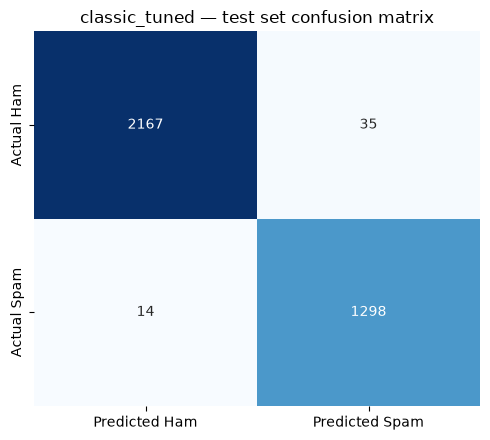

False positives (legit mail blocked): 35 of 2202 ham messages (1.6%)
False negatives (spam that got through): 14 of 1312 spam messages (1.1%)


In [19]:
final = json.loads(Path("artifacts/classic_tuned.metrics.json").read_text())
cm = final["metrics"]["confusion_matrix"]

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
    xticklabels=["Predicted Ham", "Predicted Spam"],
    yticklabels=["Actual Ham", "Actual Spam"],
)
ax.set_title("classic_tuned — test set confusion matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
print(f"False positives (legit mail blocked): {fp} of {tn+fp} ham messages ({fp/(tn+fp):.1%})")
print(f"False negatives (spam that got through): {fn} of {fn+tp} spam messages ({fn/(fn+tp):.1%})")

#### Production Inference and Load Testing

The earlier sections set two goals; build a classifier, and evaluate it for production readiness.  The notebook thus far has covered training quality, now to evaluate inference cost - how fast and effectively the model can service incoming classification requests.

To evaluate this:

- [FastAPI service](./src/capstone/app.py) was created to accept incoming requests and pass them to the models.  
- The service was packaged and executed from a [Docker](./Dockerfile) container.
- Load tests were executing using Locust, doing a parameter sweep across concurrency and request batch size, against both classic and DNN models.  
- The load test was originally run with 1 worker process, then later expanded to 4 worker processes.

To improve start-up time, importing the `tensorflow` library and configuring GPU support, was moved to be lazy-loaded only when the DNN model was loaded ([link](https://github.com/mabsimms/aiml-course-capstone/blob/c493e262ce4fd15205fa3a03ec021494d3d018e3/src/capstone/predictor.py)).


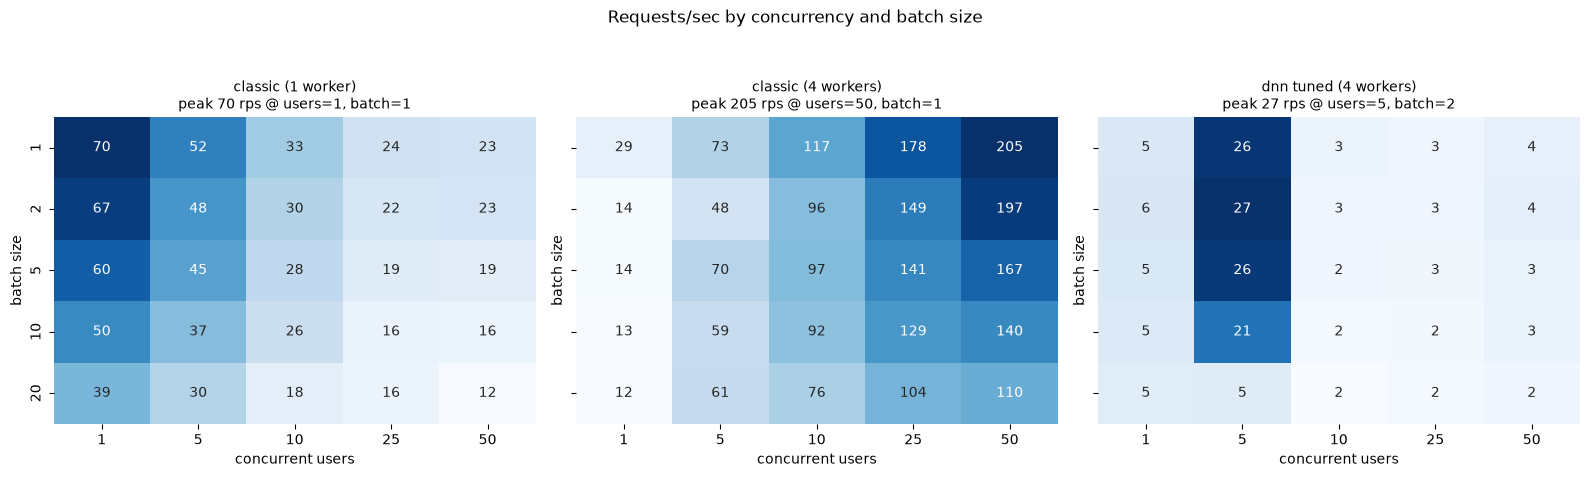

In [20]:
RUN_TAGS = {
    "classic (1 worker)": "classic-single-worker",
    "classic (4 workers)": "classic",
    "dnn tuned (4 workers)": "dnn-tuned",
}

def load_summary(tag_prefix: str) -> pd.DataFrame:
    matches = sorted(Path("loadtest-results").glob(f"{tag_prefix}-[0-9]*/summary.csv"))
    return pd.read_csv(matches[-1])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (label, tag_prefix) in zip(axes, RUN_TAGS.items()):
    df = load_summary(tag_prefix)
    pivot = df.pivot(index="batch_size", columns="users", values="rps")
    sns.heatmap(pivot, ax=ax, cmap="Blues", annot=True, fmt=".0f", cbar=False)

    peak_batch, peak_users = pivot.stack().idxmax()
    peak_rps = pivot.loc[peak_batch, peak_users]
    ax.set_title(f"{label}\npeak {peak_rps:.0f} rps @ users={peak_users}, batch={peak_batch}", fontsize=10)
    ax.set_xlabel("concurrent users")
    ax.set_ylabel("batch size")

fig.suptitle("Requests/sec by concurrency and batch size", y=1.05)
plt.tight_layout()
plt.show()

The gap is significant; classic with 4 workers peaks at 205 rps (50 users, batch size 1).  The tuned DNN with the same 4 workers peaks at 27 rps (~7.5x less throughput) with ~9x median latency at peak.  

The `classic_tuned` model is not only slightly better scoring, it is roughly an order of magnitude cheaper to serve than the DNN alternative.  In an email service provider context where this contributes to the Cost of Goods Sold (CoGS) for every single message sent, this is a material operational cost factor.

#### Conclusions and Next Steps

The data set holds about 18,600 messages from three sources, all from more than 20 years ago.  Real enterprise service provider traffic is larger and far more diverse than the available training data.  As such this project is inherently scoped to evaluating and exploring a series of techniques, with the expectation that the end result will not be production-ready for a modern deployment.

A model that tops out missing 1.1% of spam messages, and mistakenly flags 1.6% is not ready for production deployment.

Key insights:

- **Scale and diversify the training data**.  Building a production ready model and inference pipeline will require more data, and more context suitable for feature extraction. 

- **`classic_tuned` is the optimal model within the project's training scope.** The classic tuned model delivers `F1=0.9815`, and costs roughly 7.5x less to serve than the DNN under load.  Best quality and lowest cost point to the same tuned model.

- **The DNN didn't justify its training and inference cost**.  Even tuned, it was still behind classic on quality (F1 0.9741 vs. 0.9815), but at a significantly higher serving cost.

- **The DNN's quality looks like a data-scale problem, not a DNN problem**.  The tuner picked the highest dropout rate and a smaller network than the baseline (signs of overfitting).  TF-IDF already reads the distinctive vocabulary, playing to the strengths of a linear model.  DNN's would generally only pull ahead in quality given more data and signal than available in this project context.

- **The tokenizer investigation demonstrated that addressing correctness can introduce performance regressions**.  Fixing the unicode bug triggered a regression in every model.  This also highlights how important it is to invest up front in reproducible harnesses.

Potential next steps:

- **Scale and diversify the training data**.  Obtain a more robust training and validation set, and introduce more customer context for feature engineering.

- **Explore the decision threshold for tuning**.  Every result in this notebook uses the default `0.5` threshold, despite the impact asymmetry.

- **Explore using a more robust inference harness such as [ONNX](https://onnx.ai/)**.

#### Engineering Retrospective - Key Learnings

- **Reproducibility must be established up-front**.  Several of the iterations produced results that were challenging to recall or reproduce later in the project journey.  Need investments and guardrails on ensuring that results are reproducible (even if this requires a git worktree to an earlier point in time using a consistent harness and output format/convention).

- **Invest in the full round trip before investing in tuning**.  Need to ensure that the full lifecycle can be executed end to end on a baseline model configuration before investing in tuning (e.g. find issues in the production flow before optimizing).

- **Tensorflow is a fragile ecosystem; consider alternatives**.  Optimizing Tensorflow in production may require dedicated operational investments to maintain builds.



